In [45]:
import math
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt


In [46]:
n_a = 5000
conversions_a = 300
n_b = 5000
conversions_b = 450

$$ conversion\;rate = \frac{conversion_a}{n_a}$$

In [47]:
p_a = conversions_a / n_a
p_b = conversions_b / n_b

print(f"Conversion Rate Group A: {p_a*100:.2f}%")
print(f"Conversion Rate Group B: {p_b*100:.2f}%")

Conversion Rate Group A: 6.00%
Conversion Rate Group B: 9.00%


In [48]:
absolute_lift = p_b - p_a
relative_lift = absolute_lift / p_a * 100

print(f"\nAbsolute lift: {absolute_lift*100:.2f} percentage points")
print(f"Relative lift: {relative_lift:.1f}% increase")


Absolute lift: 3.00 percentage points
Relative lift: 50.0% increase


In [49]:
count = [conversions_a, conversions_b]
nobs = [n_a, n_b]

z_stat, p_value = proportions_ztest(count, nobs, alternative='two-sided')

print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.10f}")

Z-statistic: -5.6949
P-value: 0.0000000123


In [50]:
n_c, n_t = n_a, n_b
s_c, s_t = conversions_a, conversions_b
p_c, p_t = s_c/n_c, s_t/n_t

count = np.array([s_c, s_t])
nobs = np.array([n_c, n_t])
z_stat, p_value = sm.stats.proportions_ztest(count, nobs, alternative='two-sided')

ci_c = sm.stats.proportion_confint(s_c, n_c, alpha=0.05, method='normal')
ci_t = sm.stats.proportion_confint(s_t, n_t, alpha=0.05, method='normal')

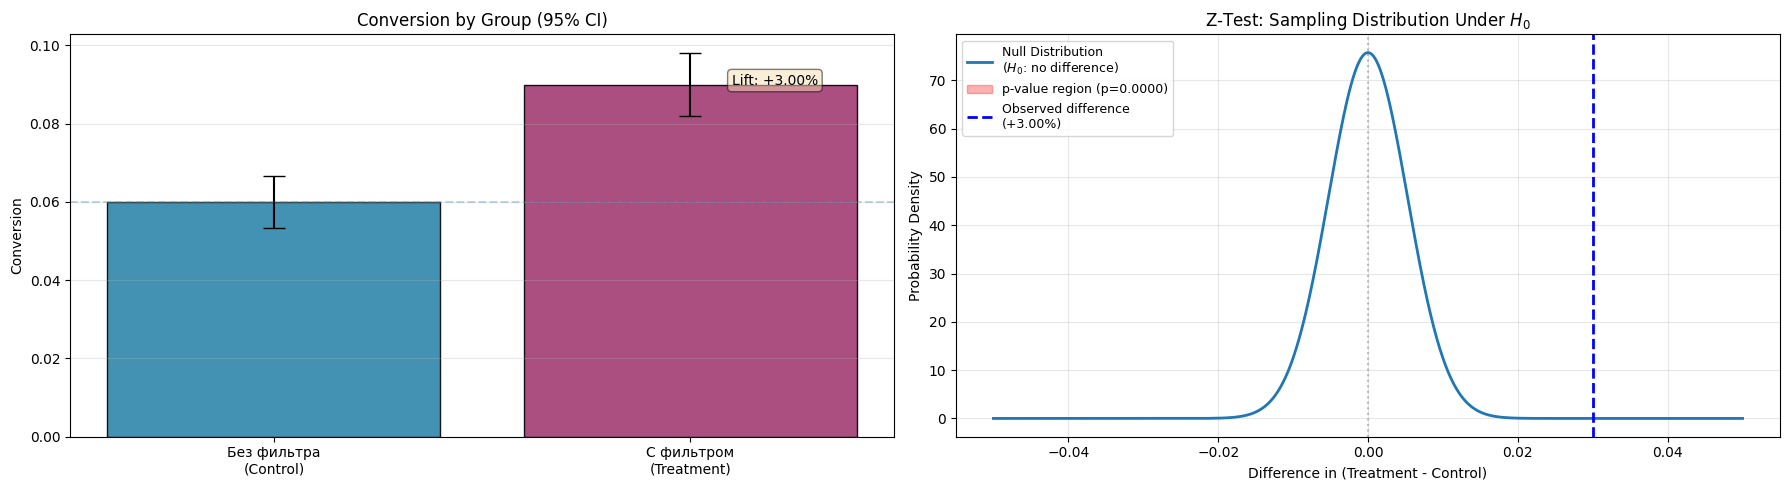

📊 Observed:
   Без фильтра: 6.00% (95% CI: [5.34%, 6.66%])
   С фильтром: 9.00% (95% CI: [8.21%, 9.79%])

🔬 Z-Test Results:
   Difference: +3.000 percentage points
   Z-statistic: -5.6949
   p-value: 0.0000
   → ✅ Significant at α=0.05


In [53]:
fig, ax = plt.subplots(1, 2, figsize=(18, 5))

groups = ['Без фильтра\n(Control)', 'С фильтром\n(Treatment)']
rates = [p_c, p_t]
errors = [(p_c - ci_c[0], ci_c[1] - p_c), 
          (p_t - ci_t[0], ci_t[1] - p_t)]

ax[0].bar(groups, rates, yerr=np.array(errors).T, capsize=8, 
          color=['#2E86AB', '#A23B72'], edgecolor='black', alpha=0.9)
ax[0].set_ylabel('Conversion')
ax[0].set_title('Conversion by Group (95% CI)')
ax[0].axhline(y=p_c, color='#2E86AB', linestyle='--', alpha=0.3)
ax[0].text(1.1, p_t, f'Lift: {(p_t-p_c)*100:+.2f}%', 
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax[0].grid(axis='y', alpha=0.3)

p_pool = (s_c + s_t) / (n_c + n_t)
se_null = np.sqrt(p_pool * (1 - p_pool) * (1/n_c + 1/n_t))

diff_obs = p_t - p_c
x = np.linspace(-0.05, 0.05, 1000)
y = stats.norm.pdf(x, loc=0, scale=se_null)

ax[1].plot(x, y, label='Null Distribution\n($H_0$: no difference)', linewidth=2)
ax[1].fill_between(x, y, where=(x <= -abs(diff_obs)) | (x >= abs(diff_obs)), 
                   alpha=0.3, color='red', label=f'p-value region (p={p_value:.4f})')
ax[1].axvline(x=diff_obs, color='blue', linestyle='--', linewidth=2, 
             label=f'Observed difference\n({diff_obs*100:+.2f}%)')
ax[1].axvline(x=0, color='gray', linestyle=':', alpha=0.5)
ax[1].set_xlabel('Difference in (Treatment - Control)')
ax[1].set_ylabel('Probability Density')
ax[1].set_title('Z-Test: Sampling Distribution Under $H_0$')
ax[1].legend(fontsize=9)
ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


print(f"📊 Observed:")
print(f"   Без фильтра: {p_c*100:.2f}% (95% CI: [{ci_c[0]*100:.2f}%, {ci_c[1]*100:.2f}%])")
print(f"   С фильтром: {p_t*100:.2f}% (95% CI: [{ci_t[0]*100:.2f}%, {ci_t[1]*100:.2f}%])")
print(f"\n🔬 Z-Test Results:")
print(f"   Difference: {(p_t - p_c)*100:+.3f} percentage points")
print(f"   Z-statistic: {z_stat:.4f}")
print(f"   p-value: {p_value:.4f}")
print(f"   → {'✅ Significant' if p_value < 0.05 else '❌ Not significant'} at α=0.05")